# Fase 3 — Preparación de los Datos
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas
**Curso:** Algoritmos y Programación III — Semestre 2026-1

---
Esta fase transforma el catálogo crudo (`labels.csv`, 19.526 imágenes) en un
conjunto **limpio, balanceado y dividido** listo para modelar, y añade la
**estimación de tamaño** mediante segmentación.

Pasos:
1. Carga y limpieza (verificación de archivos).
2. **Balanceo** por *cap* de clase de calidad (mitiga el desbalanceo 10:1).
3. **Split estratificado** 70/15/15 por calidad.
4. **Estimación de tamaño** (segmentación → diámetro normalizado → terciles).
5. Visualización y guardado de manifests.

> Toda la lógica vive en `src/` (código reutilizable y testeable); el notebook
> orquesta y documenta.

In [1]:
# Bootstrap: añadir la raíz del repo al path para poder importar `src`
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from src.config import (QUALITY_CLASSES, SIZE_CLASSES, CAP_PER_QUALITY,
                        FIGURES_DIR, PROCESSED_DIR)
from src.data import preprocessing as prep
from src.data.segmentation import segment_fruit
from src.data.paths import load_image_rgb
print("Repo:", ROOT)

Repo: /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier


## 1. Carga y limpieza
Cargamos el catálogo, filtramos a las 3 clases de calidad y verificamos que cada archivo exista en disco.

In [2]:
raw = prep.load_clean_labels()
print("Imágenes válidas:", len(raw))
dist_raw = raw['quality'].value_counts().reindex(QUALITY_CLASSES)
print("\nDistribución cruda de calidad:")
print(dist_raw)
print(f"\nDesbalanceo máx:min = {dist_raw.max()/dist_raw.min():.1f} : 1")

Imágenes válidas: 19526

Distribución cruda de calidad:
quality
Premium     11664
Estándar     1074
Descarte     6788
Name: count, dtype: int64

Desbalanceo máx:min = 10.9 : 1


## 2. Balanceo por *cap* de clase (C3)
El desbalanceo es severo (Premium domina ~10:1). Aplicamos un **cap** que
submuestrea las clases mayoritarias a `CAP_PER_QUALITY`, conservando íntegra la
clase minoritaria (Estándar). El residual lo absorberán los modelos con
`class_weight='balanced'`.

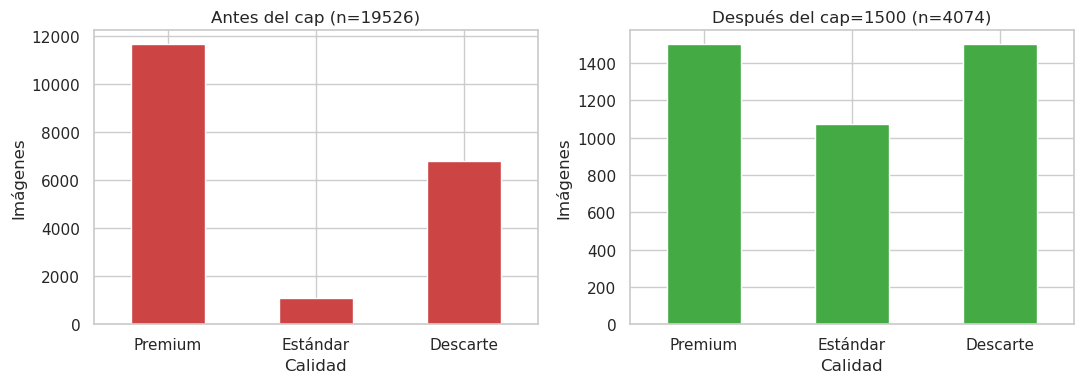

quality
Premium     1500
Estándar    1074
Descarte    1500
Name: count, dtype: int64


In [3]:
capped = prep.apply_cap(raw)
dist_cap = capped['quality'].value_counts().reindex(QUALITY_CLASSES)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dist_raw.plot.bar(ax=ax[0], color="#c44", title=f"Antes del cap (n={len(raw)})")
dist_cap.plot.bar(ax=ax[1], color="#4a4", title=f"Después del cap={CAP_PER_QUALITY} (n={len(capped)})")
for a in ax:
    a.set_xlabel("Calidad"); a.set_ylabel("Imágenes")
    a.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase3_balanceo.pdf", bbox_inches="tight")
plt.show()
print(dist_cap)

## 3. Split estratificado 70/15/15
Dividimos manteniendo la proporción de clases en cada partición (estratificación por calidad).

In [4]:
split_df = prep.stratified_split(capped)
ct = pd.crosstab(split_df['quality'], split_df['split']).reindex(QUALITY_CLASSES)[['train','val','test']]
print(ct)
print("\nProporciones por split (deben ser ~iguales entre clases):")
print((ct / ct.sum()).round(3))

split     train  val  test
quality                   
Premium    1050  225   225
Estándar    751  161   162
Descarte   1050  225   225

Proporciones por split (deben ser ~iguales entre clases):
split     train    val   test
quality                      
Premium   0.368  0.368  0.368
Estándar  0.263  0.264  0.265
Descarte  0.368  0.368  0.368


## 4. Estimación de tamaño por segmentación (C1)
Para cada imagen segmentamos la fruta (Otsu sobre saturación + morfología),
calculamos el **diámetro equivalente normalizado** por la diagonal de la imagen
y lo discretizamos en {Pequeño, Mediano, Grande} usando **terciles aprendidos
solo en train** (evita fuga de información).

In [5]:
# Pipeline completo (regenera y guarda los manifests de forma reproducible).
df = prep.build_manifests()
thr = df.attrs['size_thresholds']
print("\nUmbrales de tamaño (terciles de diámetro normalizado):")
print(f"  Pequeño  < {thr[0]:.3f}  ≤ Mediano < {thr[1]:.3f} ≤ Grande")

segmentando:   0%|          | 0/4074 [00:00<?, ?it/s]

[build] manifests guardados en /home/juan-pablo/Documents/SEMESTRE7/APO3/PF/fruit-quality-classifier/data/processed

Umbrales de tamaño (terciles de diámetro normalizado):
  Pequeño  < 0.241  ≤ Mediano < 0.390 ≤ Grande


### 4.1 Distribución del diámetro normalizado y cortes de tamaño

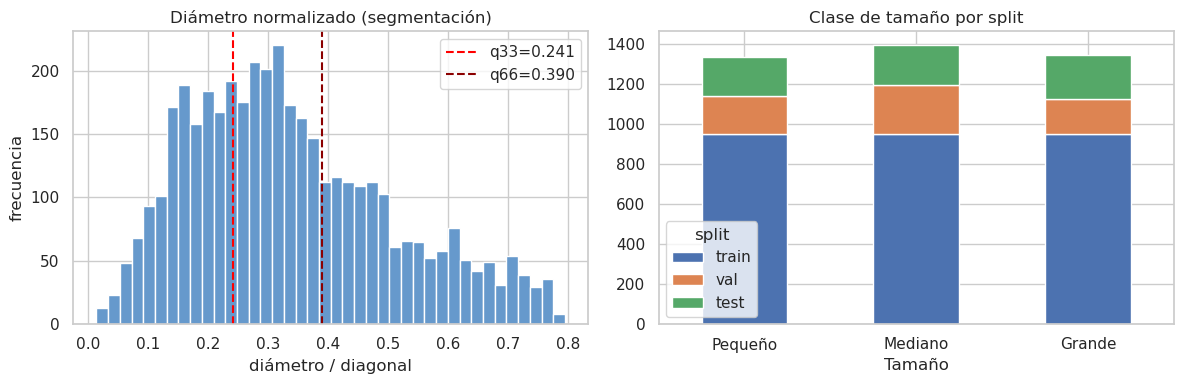

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['diameter_norm'].dropna(), bins=40, color="#69c", edgecolor="white")
ax[0].axvline(thr[0], color="red", ls="--", label=f"q33={thr[0]:.3f}")
ax[0].axvline(thr[1], color="darkred", ls="--", label=f"q66={thr[1]:.3f}")
ax[0].set_title("Diámetro normalizado (segmentación)")
ax[0].set_xlabel("diámetro / diagonal"); ax[0].set_ylabel("frecuencia"); ax[0].legend()

pd.crosstab(df['size'], df['split']).reindex(SIZE_CLASSES)[['train','val','test']].plot.bar(
    ax=ax[1], stacked=True)
ax[1].set_title("Clase de tamaño por split"); ax[1].set_xlabel("Tamaño")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase3_tamano.pdf", bbox_inches="tight")
plt.show()

### 4.2 Ejemplo visual de segmentación
Verificamos cualitativamente la segmentación sobre una muestra (imagen, máscara y bounding box + diámetro).

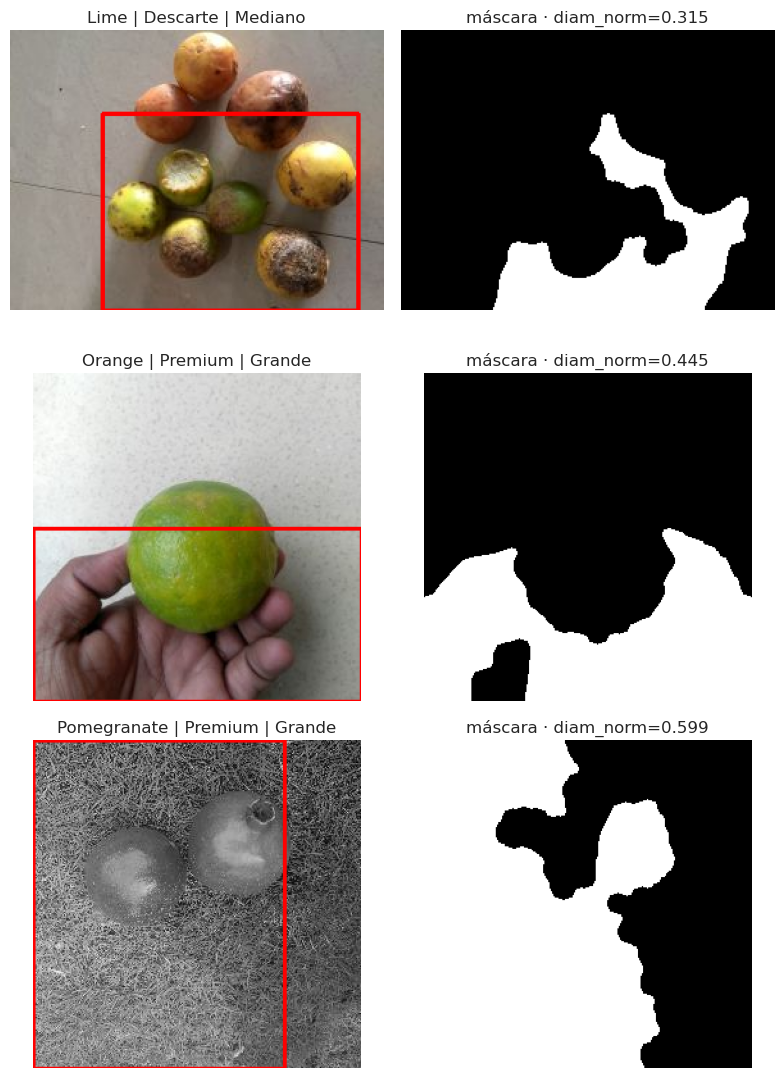

In [7]:
import cv2
samples = df.sample(3, random_state=7)
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for i, (_, row) in enumerate(samples.iterrows()):
    img = load_image_rgb(row['abs_path'])
    seg = segment_fruit(img)
    x,y,w,h = seg.bbox
    vis = img.copy()
    cv2.rectangle(vis, (x,y), (x+w,y+h), (255,0,0), max(2, img.shape[1]//150))
    axes[i,0].imshow(vis)
    axes[i,0].set_title(f"{row['fruit']} | {row['quality']} | {row['size']}")
    axes[i,1].imshow(seg.mask, cmap='gray')
    axes[i,1].set_title(f"máscara · diam_norm={seg.diameter_norm:.3f}")
    for a in axes[i]: a.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fase3_segmentacion_ejemplos.pdf", bbox_inches="tight")
plt.show()

## 5. Resumen de la Fase 3

| Artefacto | Ubicación |
|-----------|-----------|
| Manifest train/val/test | `data/processed/manifest_*.csv` |
| Figuras (balanceo, tamaño, segmentación) | `reports/figures/fase3_*.pdf` |

**Decisiones clave**
- *Cap* + `class_weight` para el desbalanceo (en vez de descartar la clase minoritaria).
- Tamaño estimado de forma **no supervisada** y reproducible (terciles en train).
- Split **estratificado** → métricas comparables entre clases.

➡️ **Siguiente:** Fase 4 — Modelado (`notebooks/4_modeling/`).